In [ ]:
'''
TODO:
- push data changes (contiguous splits)
- pull on vm and rerun optima/refitting/then this notebook
'''

'\nTODO:\n'

In [2]:
%load_ext autoreload
%autoreload 2

import importlib
import utils
import ssm

In [3]:
import torch
from gru.model import RateGRU
from utils.data import get_data, get_dmat, reshape_XY

hparams_early = {'learning_rate': 0.0045105, 'batch_size': 16, 'hidden_dim': 128} 
hparams_late  = {'learning_rate': 0.005614, 'batch_size': 16, 'hidden_dim': 128}

data_early = get_data("early")
data_late  = get_data("late")

gru_early = RateGRU(
    input_size=data_early['X_train'].shape[-1],
    hidden_size=hparams_early['hidden_dim'],
    output_size=data_early['Y_train'].shape[-1]
)
gru_late = RateGRU(
    input_size=data_late['X_train'].shape[-1],
    hidden_size=hparams_late['hidden_dim'],
    output_size=data_late['Y_train'].shape[-1]
)

ckp_early = torch.load("../vars/gru_early_best.pt", weights_only=False)
gru_early.load_state_dict(ckp_early["model_state_dict"])

# ckp_late = torch.load("../vars/gru_late_best.pt", weights_only=False)
# gru_late.load_state_dict(ckp_late["model_state_dict"])

<All keys matched successfully>

In [4]:
BWMS=10
s_per_trial=3
b_per_sec   = int(1000/BWMS)
b_per_trial = b_per_sec*s_per_trial
    
X_early, Y_early = get_dmat("early")
X_early, Y_early = reshape_XY(X_early, Y_early, b_per_trial)

In [5]:
_, h_early = gru_early.gru(torch.tensor(X_early, dtype=torch.float32))

In [8]:
h_early = h_early.detach().numpy().squeeze()

In [9]:
obs_dim   = hparams_early['hidden_dim']
state_dim = 2

print("Fitting LDS with Laplace-EM using structured variational posterior")
lds = ssm.LDS(obs_dim, state_dim, emissions="gaussian")
elbos, q = lds.fit(h_early, method="laplace_em", num_iters=10)

# get the posterior mean of the continuous states
state_means = q.mean_continuous_states[0]

# smooth the data under the variational posterior
smoothed_obs = lds.smooth(state_means, h_early)

Fitting LDS with Laplace-EM using structured variational posterior


  0%|          | 0/1 [00:00<?, ?it/s]

Initializing with an ARHMM using 25 steps of EM.


  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

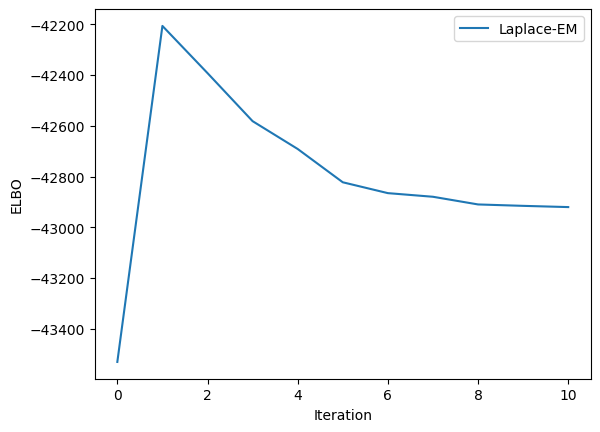

In [10]:
import matplotlib.pyplot as plt

plt.plot(elbos, label="Laplace-EM")
plt.xlabel("Iteration")
plt.ylabel("ELBO")
plt.legend()

In [14]:
import seaborn as sns
color_names = ["windows blue",
               "red",
               "amber",
               "faded green",
               "dusty purple",
               "orange",
               "clay",
               "pink",
               "greyish",
               "mint",
               "light cyan",
               "steel blue",
               "forest green",
               "pastel purple",
               "salmon",
               "dark brown"]

colors = sns.xkcd_palette(color_names)

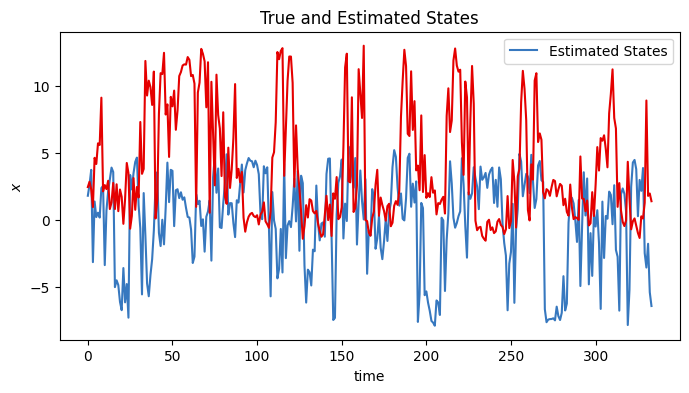

In [15]:
plt.figure(figsize=(8,4))
for d in range(state_dim):
    plt.plot(state_means[:,d] + 4 * d, '-', color=colors[d], label="Estimated States" if d==0 else None)
plt.ylabel("$x$")
plt.xlabel("time")
plt.legend(loc='upper right')
plt.title("True and Estimated States")
plt.show()

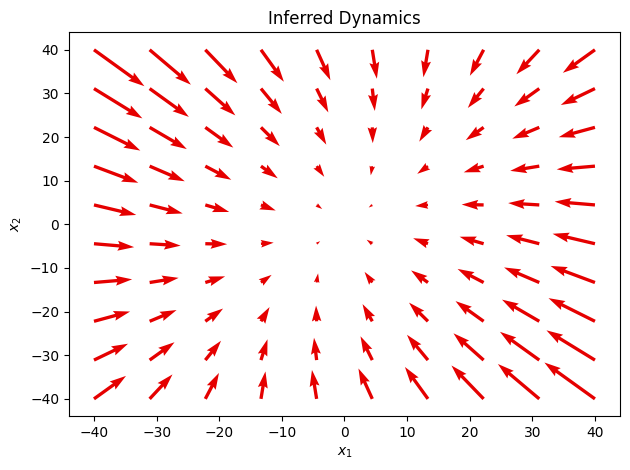

In [16]:
from ssm.plots import plot_dynamics_2d

A_est = lds.dynamics.A
b_est = lds.dynamics.b

fig, ax = plt.subplots()
plot_dynamics_2d(A_est, b_est, npts=10, axis=ax, color=colors[1])
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Inferred Dynamics")

plt.tight_layout()